In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitGaussian
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
import math

In [2]:
sim = Simulation("BFE")
switchOffAllEffects(sim)
sim["ObservingParameters/NumExposures"] = 1
sim.outputDir = os.environ["PLATO_WORKDIR"]

sim["PSF/Model"] = "MappedGaussian"
sigma = sim["PSF/MappedGaussian/Sigma"]
sim["CCD/IncludeConvolution"] = "yes"
sim["CCD/IncludeBFE"] = "yes"
numSubPixels = 16
sim["SubField/SubPixels"] = numSubPixels

sim["CCD/IncludeQuantisation"] = "yes"

In [8]:
starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"

dim = 20
numSubPixels = sim["SubField/SubPixels"]
dimSubPixels = dim * numSubPixels
Xin, Yin = np.mgrid[0:dimSubPixels, 0:dimSubPixels]

# charges = np.arange(0, 1000000, 10000)

magnitudes = np.arange(8, 20, 0.5)
widthWithBFE = np.array([])

for magnitude in magnitudes:
    
    sim.createStarCatalogFileFromPixelCoordinates(np.array([100]), np.array([100]), np.array([magnitude]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

    sim["SubField/NumRows"] = dim
    sim["SubField/NumColumns"] = dim
    sim["SubField/ZeroPointRow"] = 100 - dim // 2
    sim["SubField/ZeroPointColumn"] = 100 - dim // 2
    

    sim["ControlHDF5Content/WriteSubPixelImages"] = "yes"
    output = sim.run(removeOutputFile = True)

    params = fitGaussian(output.getSubPixelImage(0), np.max(data), dimSubPixels / 2, dimSubPixels / 2, sigma * numSubPixels, sigma * numSubPixels, subtractConstant = True)
    widthWithBFE = np.append(widthWithBFE, params[3])

In [9]:
sim["CCD/IncludeBFE"] = "no"
widthWithoutBFE = np.array([])

for magnitude in magnitudes:
    
    sim.createStarCatalogFileFromPixelCoordinates(np.array([100]), np.array([100]), np.array([magnitude]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

    sim["SubField/NumRows"] = dim
    sim["SubField/NumColumns"] = dim
    sim["SubField/ZeroPointRow"] = 100 - dim // 2
    sim["SubField/ZeroPointColumn"] = 100 - dim // 2
    

    sim["ControlHDF5Content/WriteSubPixelImages"] = "yes"
    output = sim.run(removeOutputFile = True)

    params = fitGaussian(output.getSubPixelImage(0), np.max(data), dimSubPixels / 2, dimSubPixels / 2, sigma * numSubPixels, sigma * numSubPixels)
    widthWithoutBFE = np.append(widthWithoutBFE, params[3])

Text(0, 0.5, 'FWHM of PSF [pixels]')

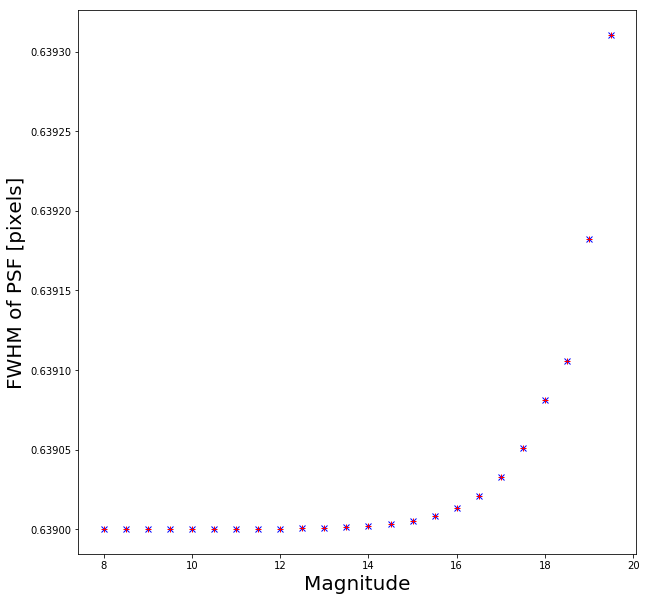

In [10]:
fig = plt.figure(figsize = (10, 10))
plt.plot(magnitudes, widthWithBFE / numSubPixels, "bx")
plt.plot(magnitudes, widthWithoutBFE / numSubPixels, "r+")

plt.xlabel("Magnitude", fontsize = 20)
plt.ylabel("FWHM of PSF [pixels]", fontsize = 20)